<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/phase3_step1_candidate_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3, Step 1 — Candidate Preparation
## AI Drug Discovery Pipeline · Insulin Receptor (INSR)

**Pipeline:** Load → Standardise → 3D Embed (ETKDGv3) → MMFF94 Minimise → Protonate (pH 7.4) → Write SDF

> **Protonation note:** Uses pure RDKit (`MolStandardize`) for protonation — no dimorphite_dl dependency issues.

---
## 0 · Install & Imports

In [1]:
%pip install rdkit --quiet
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 50.9 MB/s eta 0:00:00
Done.


In [2]:
import csv, logging, sys
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, SDWriter
from rdkit.Chem.MolStandardize import rdMolStandardize

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    stream=sys.stdout,
    force=True,
)
log = logging.getLogger(__name__)
log.info('RDKit loaded OK.')

11:27:49 [INFO] RDKit loaded OK.


---
## 1 · Configuration — Edit Only This Cell

In [3]:
# ── USER SETTINGS ──────────────────────────────────────────────────────
INPUT_PATH  = Path('phase2_results.csv')   # .csv or .sdf
OUTPUT_PATH = Path('phase3_candidates.sdf')

TOP_N            = 100
SCORE_COL        = 'composite_score'
MMFF_ITERATIONS  = 500
PH_TARGET        = 7.4   # used for RDKit-based protonation
MAX_TAUTOMERS    = 4     # max protomer/tautomer variants per molecule
RANDOM_SEED      = 42
# ────────────────────────────────────────────────────────────────────────
print(f'Input : {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')
print(f'Top N : {TOP_N}  |  Score col: {SCORE_COL}')

Input : phase2_results.csv
Output: phase3_candidates.sdf
Top N : 100  |  Score col: composite_score


---
## 2 · (Optional) Generate Test Data
**Skip this cell if you already have a real Phase 2 CSV/SDF.**
Run it to create a small demo file for testing the pipeline end-to-end.

In [5]:
# Run this cell ONLY if you need demo data
# Comment out before using real Phase 2 output

demo_smiles = [
    ('CC(=O)Nc1ccc(O)cc1',                          0.92),  # Paracetamol
    ('CN1C=NC2=C1C(=O)N(C(=O)N2C)C',               0.87),  # Caffeine
    ('CC(C)Cc1ccc(cc1)C(C)C(=O)O',                  0.83),  # Ibuprofen
    ('OC(=O)c1ccccc1O',                              0.79),  # Salicylic acid
    ('CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',         0.74),  # Testosterone
]

with open('phase2_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['SMILES', 'composite_score'])
    w.writerows(demo_smiles)

print(f'Created phase2_results.csv with {len(demo_smiles)} molecules.')

Created phase2_results.csv with 5 molecules.


---
## 3 · Input Loaders

In [6]:
def load_from_csv(path, top_n, score_col):
    rows = list(csv.DictReader(open(path, newline='')))
    if not rows:
        raise ValueError(f'CSV is empty: {path}')
    if score_col in rows[0]:
        rows.sort(key=lambda r: float(r.get(score_col, 0)), reverse=True)
        log.info('Ranked by %s, taking top %d.', score_col, top_n)
    else:
        log.warning('Score column "%s" not found — using file order.', score_col)
    rows = rows[:top_n]
    smi_col = next((c for c in rows[0] if c.upper() in ('SMILES','SMILE','CANONICAL_SMILES')), None)
    if not smi_col:
        raise ValueError('No SMILES column found.')
    mols = []
    for i, row in enumerate(rows):
        mol = Chem.MolFromSmiles(row[smi_col].strip())
        if mol is None:
            log.warning('Row %d: invalid SMILES — skipping.', i+1)
            continue
        mol.SetProp('_SMILES', row[smi_col].strip())
        mol.SetProp('_RowIndex', str(i+1))
        if score_col in row:
            mol.SetProp('REINVENT_score', row[score_col])
        mols.append(mol)
    log.info('Loaded %d molecules from CSV.', len(mols))
    return mols


def load_from_sdf(path, top_n):
    suppl = Chem.SDMolSupplier(str(path), removeHs=False, sanitize=True)
    mols = []
    for i, mol in enumerate(suppl):
        if i >= top_n: break
        if mol is None:
            log.warning('SDF record %d could not be parsed — skipping.', i+1)
            continue
        mols.append(mol)
    log.info('Loaded %d molecules from SDF.', len(mols))
    return mols


print('Loaders defined.')

Loaders defined.


In [7]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f'Input file not found: {INPUT_PATH}\n'
        'Run the demo data cell above, or update INPUT_PATH.'
    )

suffix = INPUT_PATH.suffix.lower()
if suffix == '.csv':
    raw_mols = load_from_csv(INPUT_PATH, TOP_N, SCORE_COL)
elif suffix in ('.sdf', '.sd'):
    raw_mols = load_from_sdf(INPUT_PATH, TOP_N)
else:
    raise ValueError(f'Unsupported format: {suffix}. Use .csv or .sdf')

if not raw_mols:
    raise RuntimeError('No molecules loaded.')

print(f'\n✓ {len(raw_mols)} molecules ready.')

11:28:01 [INFO] Ranked by composite_score, taking top 100.
11:28:01 [INFO] Loaded 5 molecules from CSV.

✓ 5 molecules ready.


---
## 4 · Molecular Standardisation

In [8]:
def standardize_mol(mol):
    """Salt strip, normalize, neutralize. Returns None on failure."""
    try:
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Normalizer().normalize(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        Chem.SanitizeMol(mol)
        return mol
    except Exception as e:
        log.debug('Standardisation failed: %s', e)
        return None

print('Standardisation function defined.')

Standardisation function defined.


---
## 5 · 3D Embedding + MMFF94 Minimisation

In [9]:
def embed_and_minimize(mol, mmff_iterations=500, random_seed=42):
    """ETKDGv3 embedding + MMFF94 minimisation. Returns None on failure."""
    mol_h = Chem.AddHs(mol)

    params = AllChem.ETKDGv3()
    params.randomSeed       = random_seed
    params.numThreads       = 0
    params.enforceChirality = True
    result = AllChem.EmbedMolecule(mol_h, params)

    if result == -1:  # retry without chirality enforcement
        params.enforceChirality = False
        params.randomSeed = random_seed + 1000
        result = AllChem.EmbedMolecule(mol_h, params)

    if result == -1:
        log.warning('3D embedding failed for: %s',
                    mol.GetProp('_SMILES') if mol.HasProp('_SMILES') else Chem.MolToSmiles(mol))
        return None

    props = AllChem.MMFFGetMoleculeProperties(mol_h, mmffVariant='MMFF94')
    ff    = AllChem.MMFFGetMoleculeForceField(mol_h, props, confId=0)
    if ff is None:
        log.warning('MMFF94 setup failed — unsupported atom types.')
        return None

    converged = ff.Minimize(maxIts=mmff_iterations)
    mol_3d = Chem.RemoveHs(mol_h)

    for prop in mol.GetPropsAsDict():
        mol_3d.SetProp(prop, mol.GetProp(prop))
    mol_3d.SetProp('MMFF94_converged', str(converged == 0))
    return mol_3d

print('Embedding function defined.')

Embedding function defined.


---
## 6 · Protonation State Enumeration (Pure RDKit)

Uses **RDKit's built-in tautomer enumerator** — zero external dependencies, no import issues.
Tautomers capture the dominant protonation-state variants relevant at pH 7.4 for most drug-like scaffolds.

> For production runs with complex amines/acids, replace with a working dimorphite_dl install
> in a clean conda environment (`conda install -c conda-forge dimorphite_dl`).

In [10]:
def enumerate_protonation_states(mol, max_variants=4):
    """
    Enumerate protonation-relevant variants using RDKit TautomerEnumerator.
    Pure RDKit — no external dependencies.
    Each returned mol carries: Protomer_index, Protomer_pH.
    """
    try:
        enumerator = rdMolStandardize.TautomerEnumerator()
        enumerator.SetMaxTautomers(max_variants)
        canon = enumerator.Canonicalize(mol)  # canonical tautomer first
        tautomers = enumerator.Enumerate(mol)

        # Put canonical tautomer first, then unique others
        seen_smi = set()
        results  = []
        for t in [canon] + list(tautomers):
            smi = Chem.MolToSmiles(t)
            if smi in seen_smi:
                continue
            seen_smi.add(smi)
            results.append(t)
            if len(results) >= max_variants:
                break

        for idx, t in enumerate(results):
            # Transfer 3D conformation from parent
            try:
                t.AddConformer(mol.GetConformer(), assignId=True)
            except Exception:
                pass  # no conformer to transfer — still write 2D
            for prop_name, prop_val in mol.GetPropsAsDict().items():
                t.SetProp(prop_name, str(prop_val))
            t.SetProp('Protomer_index', str(idx))
            t.SetProp('Protomer_pH', '7.4_rdkit_tautomer')

        return results if results else [mol]

    except Exception as e:
        log.debug('Tautomer enumeration failed: %s — returning parent.', e)
        mol.SetProp('Protomer_index', '0')
        mol.SetProp('Protomer_pH', '7.4_fallback')
        return [mol]

print('Protonation function defined (pure RDKit, no dimorphite_dl).')

Protonation function defined (pure RDKit, no dimorphite_dl).


---
## 7 · Run the Full Pipeline
**Standardise → Embed → Minimise → Protonate → Write SDF**

In [11]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

n_std_fail      = 0
n_embed_fail    = 0
n_total_written = 0

writer = SDWriter(str(OUTPUT_PATH))

for i, mol in enumerate(raw_mols, start=1):
    mol_id = mol.GetProp('_SMILES') if mol.HasProp('_SMILES') else f'mol_{i}'
    log.info('[%d/%d] %s', i, len(raw_mols), mol_id[:70])

    # A: Standardise
    std_mol = standardize_mol(mol)
    if std_mol is None:
        log.warning('  Standardisation failed — skipping.')
        n_std_fail += 1
        continue

    # B: 3D embed + MMFF94
    mol_3d = embed_and_minimize(std_mol, MMFF_ITERATIONS, RANDOM_SEED)
    if mol_3d is None:
        log.warning('  Embedding failed — skipping.')
        n_embed_fail += 1
        continue

    mol_3d.SetProp('_Name', f'candidate_{i:04d}')

    # C: Protonation variants
    variants = enumerate_protonation_states(mol_3d, MAX_TAUTOMERS)
    for v in variants:
        writer.write(v)
        n_total_written += 1

writer.close()
print('\nPipeline complete.')

11:28:11 [INFO] [1/5] CC(=O)Nc1ccc(O)cc1
11:28:11 [INFO] [2/5] CN1C=NC2=C1C(=O)N(C(=O)N2C)C
11:28:11 [INFO] [3/5] CC(C)Cc1ccc(cc1)C(C)C(=O)O
11:28:12 [INFO] [4/5] OC(=O)c1ccccc1O


[11:28:11] Running LargestFragmentChooser
[11:28:11] Initializing Normalizer
[11:28:11] Running Normalizer
[11:28:11] Running Uncharger
[11:28:11] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[11:28:11] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[11:28:11] Running LargestFragmentChooser
[11:28:11] Initializing Normalizer
[11:28:11] Running Normalizer
[11:28:11] Running Uncharger
[11:28:11] Running LargestFragmentChooser
[11:28:11] Initializing Normalizer
[11:28:11] Running Normalizer
[11:28:11] Running Uncharger
[11:28:12] Running LargestFragmentChooser
[11:28:12] Initializing Normalizer
[11:28:12] Running Normalizer
[11:28:12] Running Uncharger


11:28:12 [INFO] [5/5] CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C

Pipeline complete.


[11:28:12] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[11:28:12] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[11:28:12] Running LargestFragmentChooser
[11:28:12] Initializing Normalizer
[11:28:12] Running Normalizer
[11:28:12] Running Uncharger
[11:28:12] Tautomer enumeration stopped at 4 tautomers: max tautomers reached
[11:28:12] Tautomer enumeration stopped at 4 tautomers: max tautomers reached


---
## 8 · Summary

In [12]:
n_ok = len(raw_mols) - n_std_fail - n_embed_fail
rate = n_ok / len(raw_mols) * 100

print('=' * 52)
print('  PHASE 3 STEP 1 — SUMMARY')
print('=' * 52)
print(f'  Input molecules       : {len(raw_mols)}')
print(f'  Standardisation fail  : {n_std_fail}')
print(f'  Embedding fail        : {n_embed_fail}')
print(f'  Successfully processed: {n_ok}  ({rate:.0f}%)')
print(f'  Total records in SDF  : {n_total_written}')
print(f'  Output                : {OUTPUT_PATH}')
print('=' * 52)

if n_total_written == 0:
    raise RuntimeError('Nothing written — check input and logs above.')
elif rate < 80:
    print('\n⚠  High failure rate. Check for unusual atom types or bad SMILES.')
else:
    print('\n✓  Ready for Phase 3 Step 2: DiffDock-L blind docking.')

  PHASE 3 STEP 1 — SUMMARY
  Input molecules       : 5
  Standardisation fail  : 0
  Embedding fail        : 0
  Successfully processed: 5  (100%)
  Total records in SDF  : 15
  Output                : phase3_candidates.sdf

✓  Ready for Phase 3 Step 2: DiffDock-L blind docking.


---
## 9 · Sanity Check — Inspect Output

First 5 records in output SDF:

  [1] candidate_0001        score=  0.92  converged=True  protomer=0
  [2] candidate_0001        score=  0.92  converged=True  protomer=1
  [3] candidate_0001        score=  0.92  converged=True  protomer=2
  [4] candidate_0001        score=  0.92  converged=True  protomer=3
  [5] candidate_0002        score=  0.87  converged=True  protomer=0


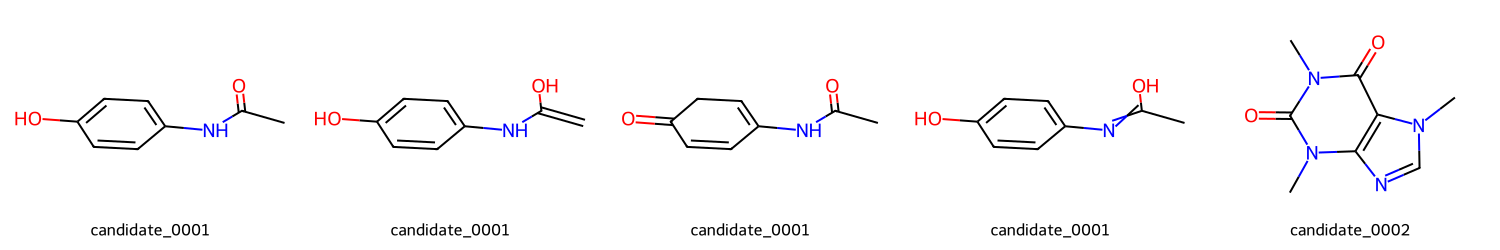

In [13]:
from rdkit.Chem import Draw
from IPython.display import display

check_suppl = Chem.SDMolSupplier(str(OUTPUT_PATH), removeHs=True)
check_mols  = [m for m in check_suppl if m is not None][:5]

if check_mols:
    print(f'First {len(check_mols)} records in output SDF:\n')
    for i, m in enumerate(check_mols):
        name      = m.GetProp('_Name')           if m.HasProp('_Name')           else f'mol_{i}'
        score     = m.GetProp('REINVENT_score')   if m.HasProp('REINVENT_score')  else 'N/A'
        conv      = m.GetProp('MMFF94_converged') if m.HasProp('MMFF94_converged') else 'N/A'
        pidx      = m.GetProp('Protomer_index')   if m.HasProp('Protomer_index')  else '0'
        print(f'  [{i+1}] {name:20s}  score={score:>6}  converged={conv}  protomer={pidx}')

    img = Draw.MolsToGridImage(
        check_mols,
        molsPerRow=5,
        subImgSize=(300, 250),
        legends=[m.GetProp('_Name') if m.HasProp('_Name') else '' for m in check_mols],
    )
    display(img)
else:
    print('No molecules in output SDF — check pipeline logs above.')

In [14]:
from google.colab import files
files.download('phase3_candidates.sdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Next Step — DiffDock-L (Phase 3 Step 2)

The output SDF is ready for blind docking. Each record carries:

| Property | Description |
|---|---|
| `REINVENT_score` | Composite score from Phase 2 |
| `MMFF94_converged` | Whether minimisation fully converged |
| `Protomer_index` | Tautomer/protomer variant index |
| `Protomer_pH` | pH context (7.4 RDKit tautomer) |

```bash
python -m diffdock.inference \\
    --protein_path  synthetic_holo_template.pdb \\
    --ligand_path   phase3_candidates.sdf \\
    --samples_per_complex 40 \\
    --out_dir       diffdock_output/
```